In [12]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Importing Success")
print(f"Version of Numpy = {np.__version__} and Pandas = {pd.__version__}")

Importing Success
Version of Numpy = 2.4.6 and Pandas = 3.0.3


In [13]:
#data path
data_path = "../data/MachineLearningCVE"

#listing all csv files
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
csv_files.sort()

print(f"Number of CSV files found: {len(csv_files)}")
print("\nFiles:")
for f in csv_files:
    print(f" {f}")

Number of CSV files found: 8

Files:
 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 Friday-WorkingHours-Morning.pcap_ISCX.csv
 Monday-WorkingHours.pcap_ISCX.csv
 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 Tuesday-WorkingHours.pcap_ISCX.csv
 Wednesday-workingHours.pcap_ISCX.csv


In [14]:
# Load csv into one dataframe
dfs = []

for f in csv_files:
    file_path = os.path.join(data_path, f)
    df_temp = pd.read_csv(file_path, encoding='utf-8', low_memory=False)
    print(f"{f}: {df_temp.shape[0]:,} rows, {df_temp.shape[1]} columns")
    dfs.append(df_temp)

#Combining all files into one
df = pd.concat(dfs, ignore_index = True)
print(f"\nTotal Dataset Shape : {df.shape[0]:,} rows, {df.shape[1]} columns")

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows, 79 columns
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows, 79 columns
Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows, 79 columns
Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows, 79 columns
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows, 79 columns
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows, 79 columns
Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows, 79 columns
Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows, 79 columns

Total Dataset Shape : 2,830,743 rows, 79 columns


In [15]:
# dataset basic info
print(f"Dataset Shape: {df.shape}")
print("\nColumn Names")
for i, col in enumerate(df.columns):
    print(f"  {i + 1}. {col}:")

Dataset Shape: (2830743, 79)

Column Names
  1.  Destination Port:
  2.  Flow Duration:
  3.  Total Fwd Packets:
  4.  Total Backward Packets:
  5. Total Length of Fwd Packets:
  6.  Total Length of Bwd Packets:
  7.  Fwd Packet Length Max:
  8.  Fwd Packet Length Min:
  9.  Fwd Packet Length Mean:
  10.  Fwd Packet Length Std:
  11. Bwd Packet Length Max:
  12.  Bwd Packet Length Min:
  13.  Bwd Packet Length Mean:
  14.  Bwd Packet Length Std:
  15. Flow Bytes/s:
  16.  Flow Packets/s:
  17.  Flow IAT Mean:
  18.  Flow IAT Std:
  19.  Flow IAT Max:
  20.  Flow IAT Min:
  21. Fwd IAT Total:
  22.  Fwd IAT Mean:
  23.  Fwd IAT Std:
  24.  Fwd IAT Max:
  25.  Fwd IAT Min:
  26. Bwd IAT Total:
  27.  Bwd IAT Mean:
  28.  Bwd IAT Std:
  29.  Bwd IAT Max:
  30.  Bwd IAT Min:
  31. Fwd PSH Flags:
  32.  Bwd PSH Flags:
  33.  Fwd URG Flags:
  34.  Bwd URG Flags:
  35.  Fwd Header Length:
  36.  Bwd Header Length:
  37. Fwd Packets/s:
  38.  Bwd Packets/s:
  39.  Min Packet Length:
  40.  Max

In [16]:
#class distribution
print("Class Distribution")
print(df[' Label'].value_counts())
print("\nClass Distribution (%):")
print(df[' Label'].value_counts(normalize=True).mul(100).round(2))

Class Distribution
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Class Distribution (%):
 Label
BENIGN                        80.30
DoS Hulk                       8.16
PortScan                       5.61
DDoS                           4.52
DoS GoldenEye                  0.36
FTP-Patator                    0.28
SSH-Patator                    0.21
DoS slowloris                  0.20
DoS Slowhttptest               0.19
Bot                   

/var/folders/zy/szwpfn290db_b_7d_thzbd700000gn/T/ipykernel_15299/3926120910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[' Label'].value_counts().values,


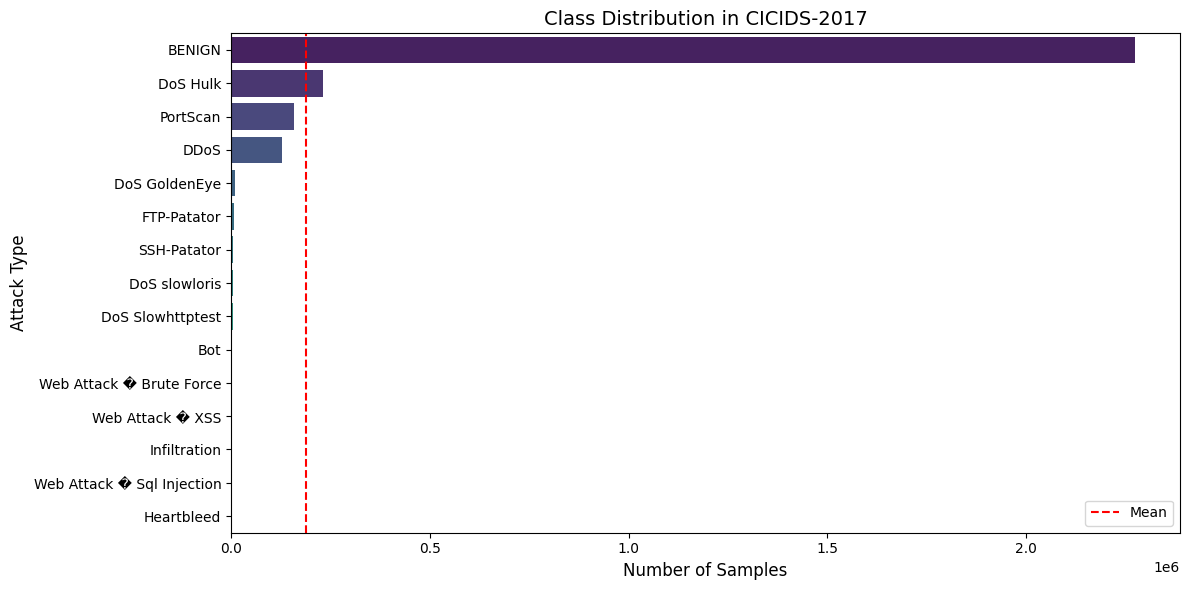

Plot saved to results folder


In [17]:
#visualize
# Visualize class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=df[' Label'].value_counts().values, 
            y=df[' Label'].value_counts().index,
            palette='viridis')

plt.title('Class Distribution in CICIDS-2017', fontsize=14)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)
plt.axvline(x=df[' Label'].value_counts().mean(), 
            color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to results folder")

The red dashed line is the mean (average) number of samples per class.
BENIGN bar stretches to 2.27 million: so far right it goes off proportion compared to everything else.
Heartbleed, SQL Injection, Infiltration: their bars are literally invisible. Too small to even render on this scale.

What This Visually Proves
Every class that falls left of the red line is a minority class. That's almost every attack type. Every class right of the red line is dominating the dataset. That's only BENIGN.
A standard model trained on this data learns:

"Almost everything is benign, so predict benign"

And it scores 80% accuracy while missing Heartbleed every single time.


In [18]:
# Clean column names - remove leading/trailing spaces
df.columns = df.columns.str.strip()

# Check for missing values
print("Missing Values Per Column:")
missing = df.isnull().sum() 
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for infinite values
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"Total infinite values: {inf_count}")

Missing Values Per Column:
Flow Bytes/s    1358
dtype: int64

Total missing values: 1358
Total infinite values: 4376


In [19]:
# replacing inf values with NaN

df.replace([np.inf, -np.inf],np.nan, inplace=True)

#drop NaN values
df.dropna(inplace=True)

print(f"Rows after cleaning: {df.shape[0]:,}")
print(f"Remaning missing values: {df.isnull().sum().sum()}")
print(f"Remaning infininte values: {np.isinf(df[numeric_cols]).sum().sum()}")

Rows after cleaning: 2,827,876
Remaning missing values: 0
Remaning infininte values: 0


In [20]:
# Basic statistics of all numerical features
print("Dataset Statistics:")
print(df.describe().T)

Dataset Statistics:
                                 count          mean           std   min  \
Destination Port             2827876.0  8.061534e+03  1.827432e+04   0.0   
Flow Duration                2827876.0  1.480065e+07  3.366750e+07 -13.0   
Total Fwd Packets            2827876.0  9.368972e+00  7.500527e+02   1.0   
Total Backward Packets       2827876.0  1.040396e+01  9.978937e+02   0.0   
Total Length of Fwd Packets  2827876.0  5.498522e+02  9.998639e+03   0.0   
...                                ...           ...           ...   ...   
Active Min                   2827876.0  5.835492e+04  5.773818e+05   0.0   
Idle Mean                    2827876.0  8.324468e+06  2.364057e+07   0.0   
Idle Std                     2827876.0  5.043548e+05  4.605289e+06   0.0   
Idle Max                     2827876.0  8.704568e+06  2.437766e+07   0.0   
Idle Min                     2827876.0  7.928061e+06  2.337390e+07   0.0   

                               25%      50%         75%          ma

## Dataset Statistics Reference — `.describe()` output

| Column | What it means for this dataset |
|--------|-------------------------------|
| `count` | All 2,827,876 : no missing values after cleaning |
| `mean` | Average value : unreliable alone due to outliers |
| `std` | Spread : Total Fwd Packets std=750 >> mean=9 → attack outliers |
| `min` | Flow Duration min=-13 → impossible, data error in CICFlowMeter |
| `50%` | True typical value : more reliable than mean |
| `mean vs 50%` | Flow Duration mean=14.8M vs median=31,338 → massive outliers = attacks |
| `max` | Extreme values e.g. 219,759 packets : fix later during normalization |

**Key insight:** Mean >> Median in this dataset → attack traffic creating extreme outliers

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis = 1)
y = df['Label']

#Test Set 
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# train and validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

#verify size
print(f"Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

Training set:   1,980,643 rows (70.0%)
Validation set: 423,051 rows (15.0%)
Test set:       424,182 rows (15.0%)


In [22]:
# Save the cleaned splits for later use
import os

save_path = "../data/processed/"
os.makedirs(save_path, exist_ok=True)

X_train.to_csv(save_path + "X_train.csv", index=False)
X_val.to_csv(save_path + "X_val.csv", index=False)
X_test.to_csv(save_path + "X_test.csv", index=False)
y_train.to_csv(save_path + "y_train.csv", index=False)
y_val.to_csv(save_path + "y_val.csv", index=False)
y_test.to_csv(save_path + "y_test.csv", index=False)

print("All splits saved successfully")
print(f"Saved to: {os.path.abspath(save_path)}")

All splits saved successfully
Saved to: /Users/kdhungel/Desktop/Everything/Learning Zone/MS Computational Scinece/Term 2/Project/Work/iads-project/data/processed
